#### Uyenmy Nguyen
#### Research Question: Which tree tyoe would cover best in a specific wilderness according to its characteristic?

## 1. Load the dataset-------------------------------------------------------------------------

In [1]:
# import neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/forest-cover-type-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'forest-cover-type-dataset' dataset.
Path to dataset files: /kaggle/input/forest-cover-type-dataset


In [3]:
# Load the dataset
fct = pd.read_csv(path + "/covtype.csv")
fct.head(10)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
6,2606,45,7,270,5,633,222,225,138,6256,...,0,0,0,0,0,0,0,0,0,5
7,2605,49,4,234,7,573,222,230,144,6228,...,0,0,0,0,0,0,0,0,0,5
8,2617,45,9,240,56,666,223,221,133,6244,...,0,0,0,0,0,0,0,0,0,5
9,2612,59,10,247,11,636,228,219,124,6230,...,0,0,0,0,0,0,0,0,0,5


## 2. Explore Data Analysis (EDA)-----------------------------------------------------------------

In [4]:
# check for rows and columns
fct.shape

(581012, 55)

In [5]:
# Check all column name
print("\nColumn name:")
print(fct.columns.tolist())


Column name:
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']


In [6]:
# check for data type
fct.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

Mostly numerical values appeared!

In [7]:
# check for missing values
print('All Missing Values per Column:')
print(fct.isnull().sum())

All Missing Values per Column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type

NO missing values shown!!

<Axes: >

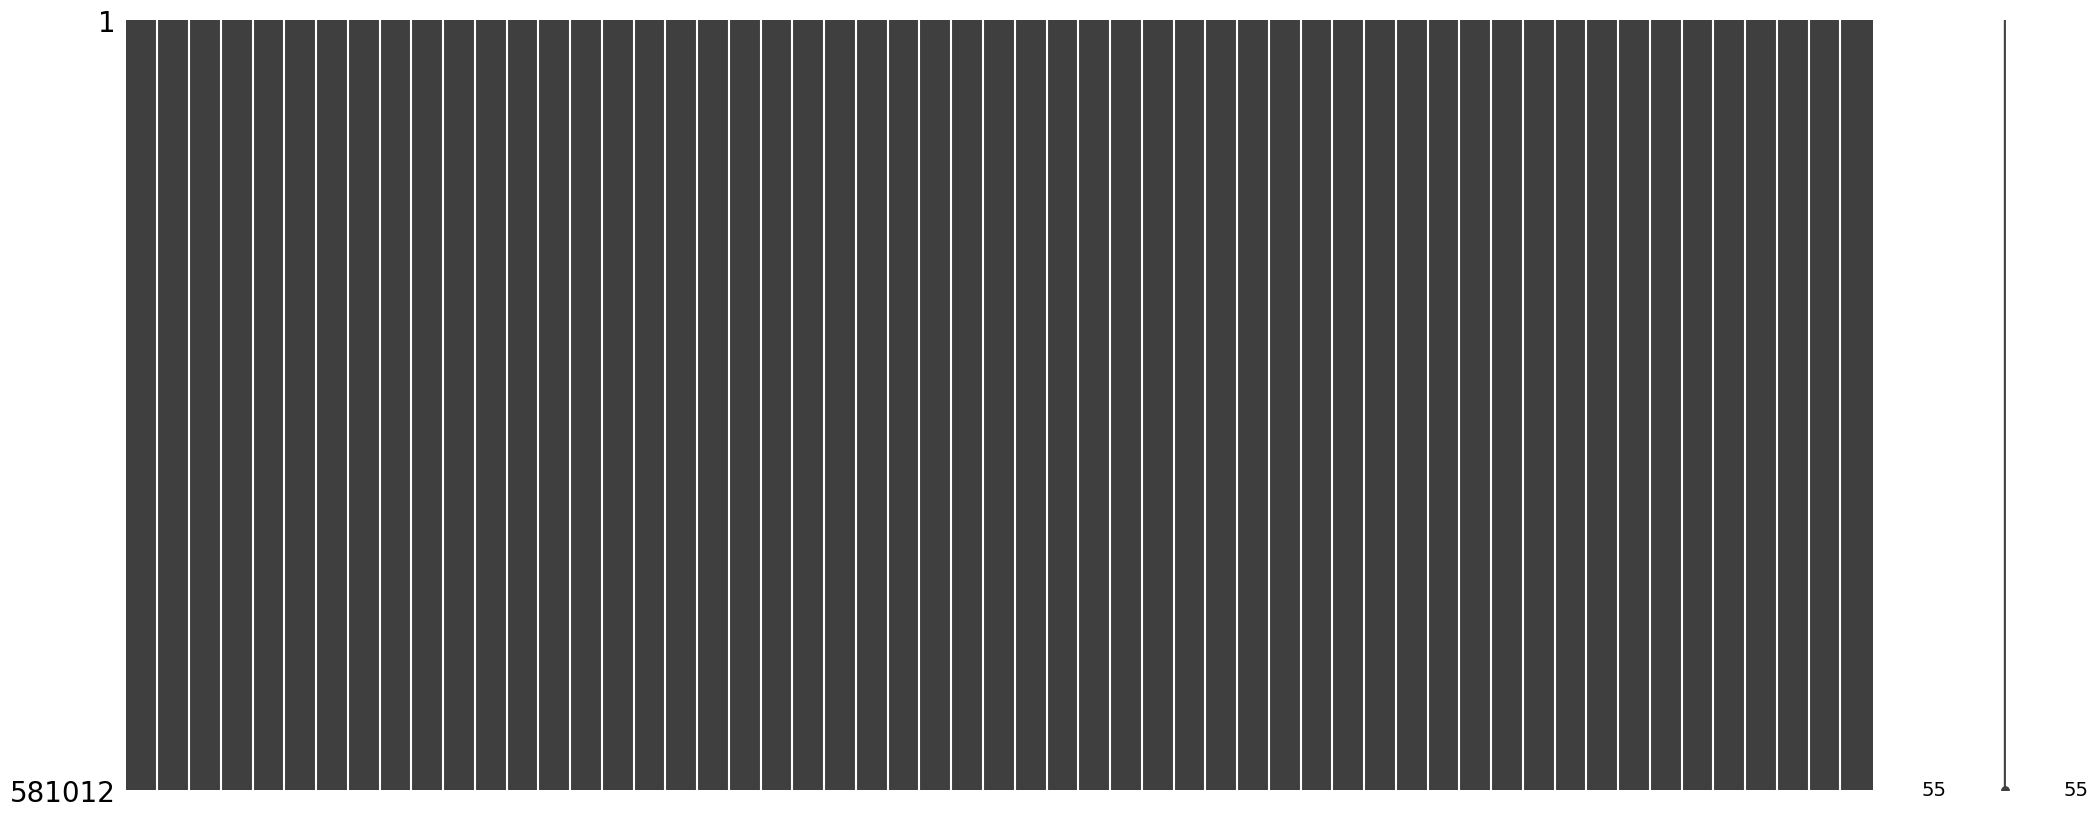

In [8]:
# visualize for missing values
import missingno as msno
msno.matrix(fct)

* Dark: values present
* White space: missingness
* Conclusion: no missingness appear!

In [9]:
# check for duplicates
print('Duplicate:', fct.duplicated().sum())

Duplicate: 0


In [10]:
# check for statistical informations in the dataset
fct.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


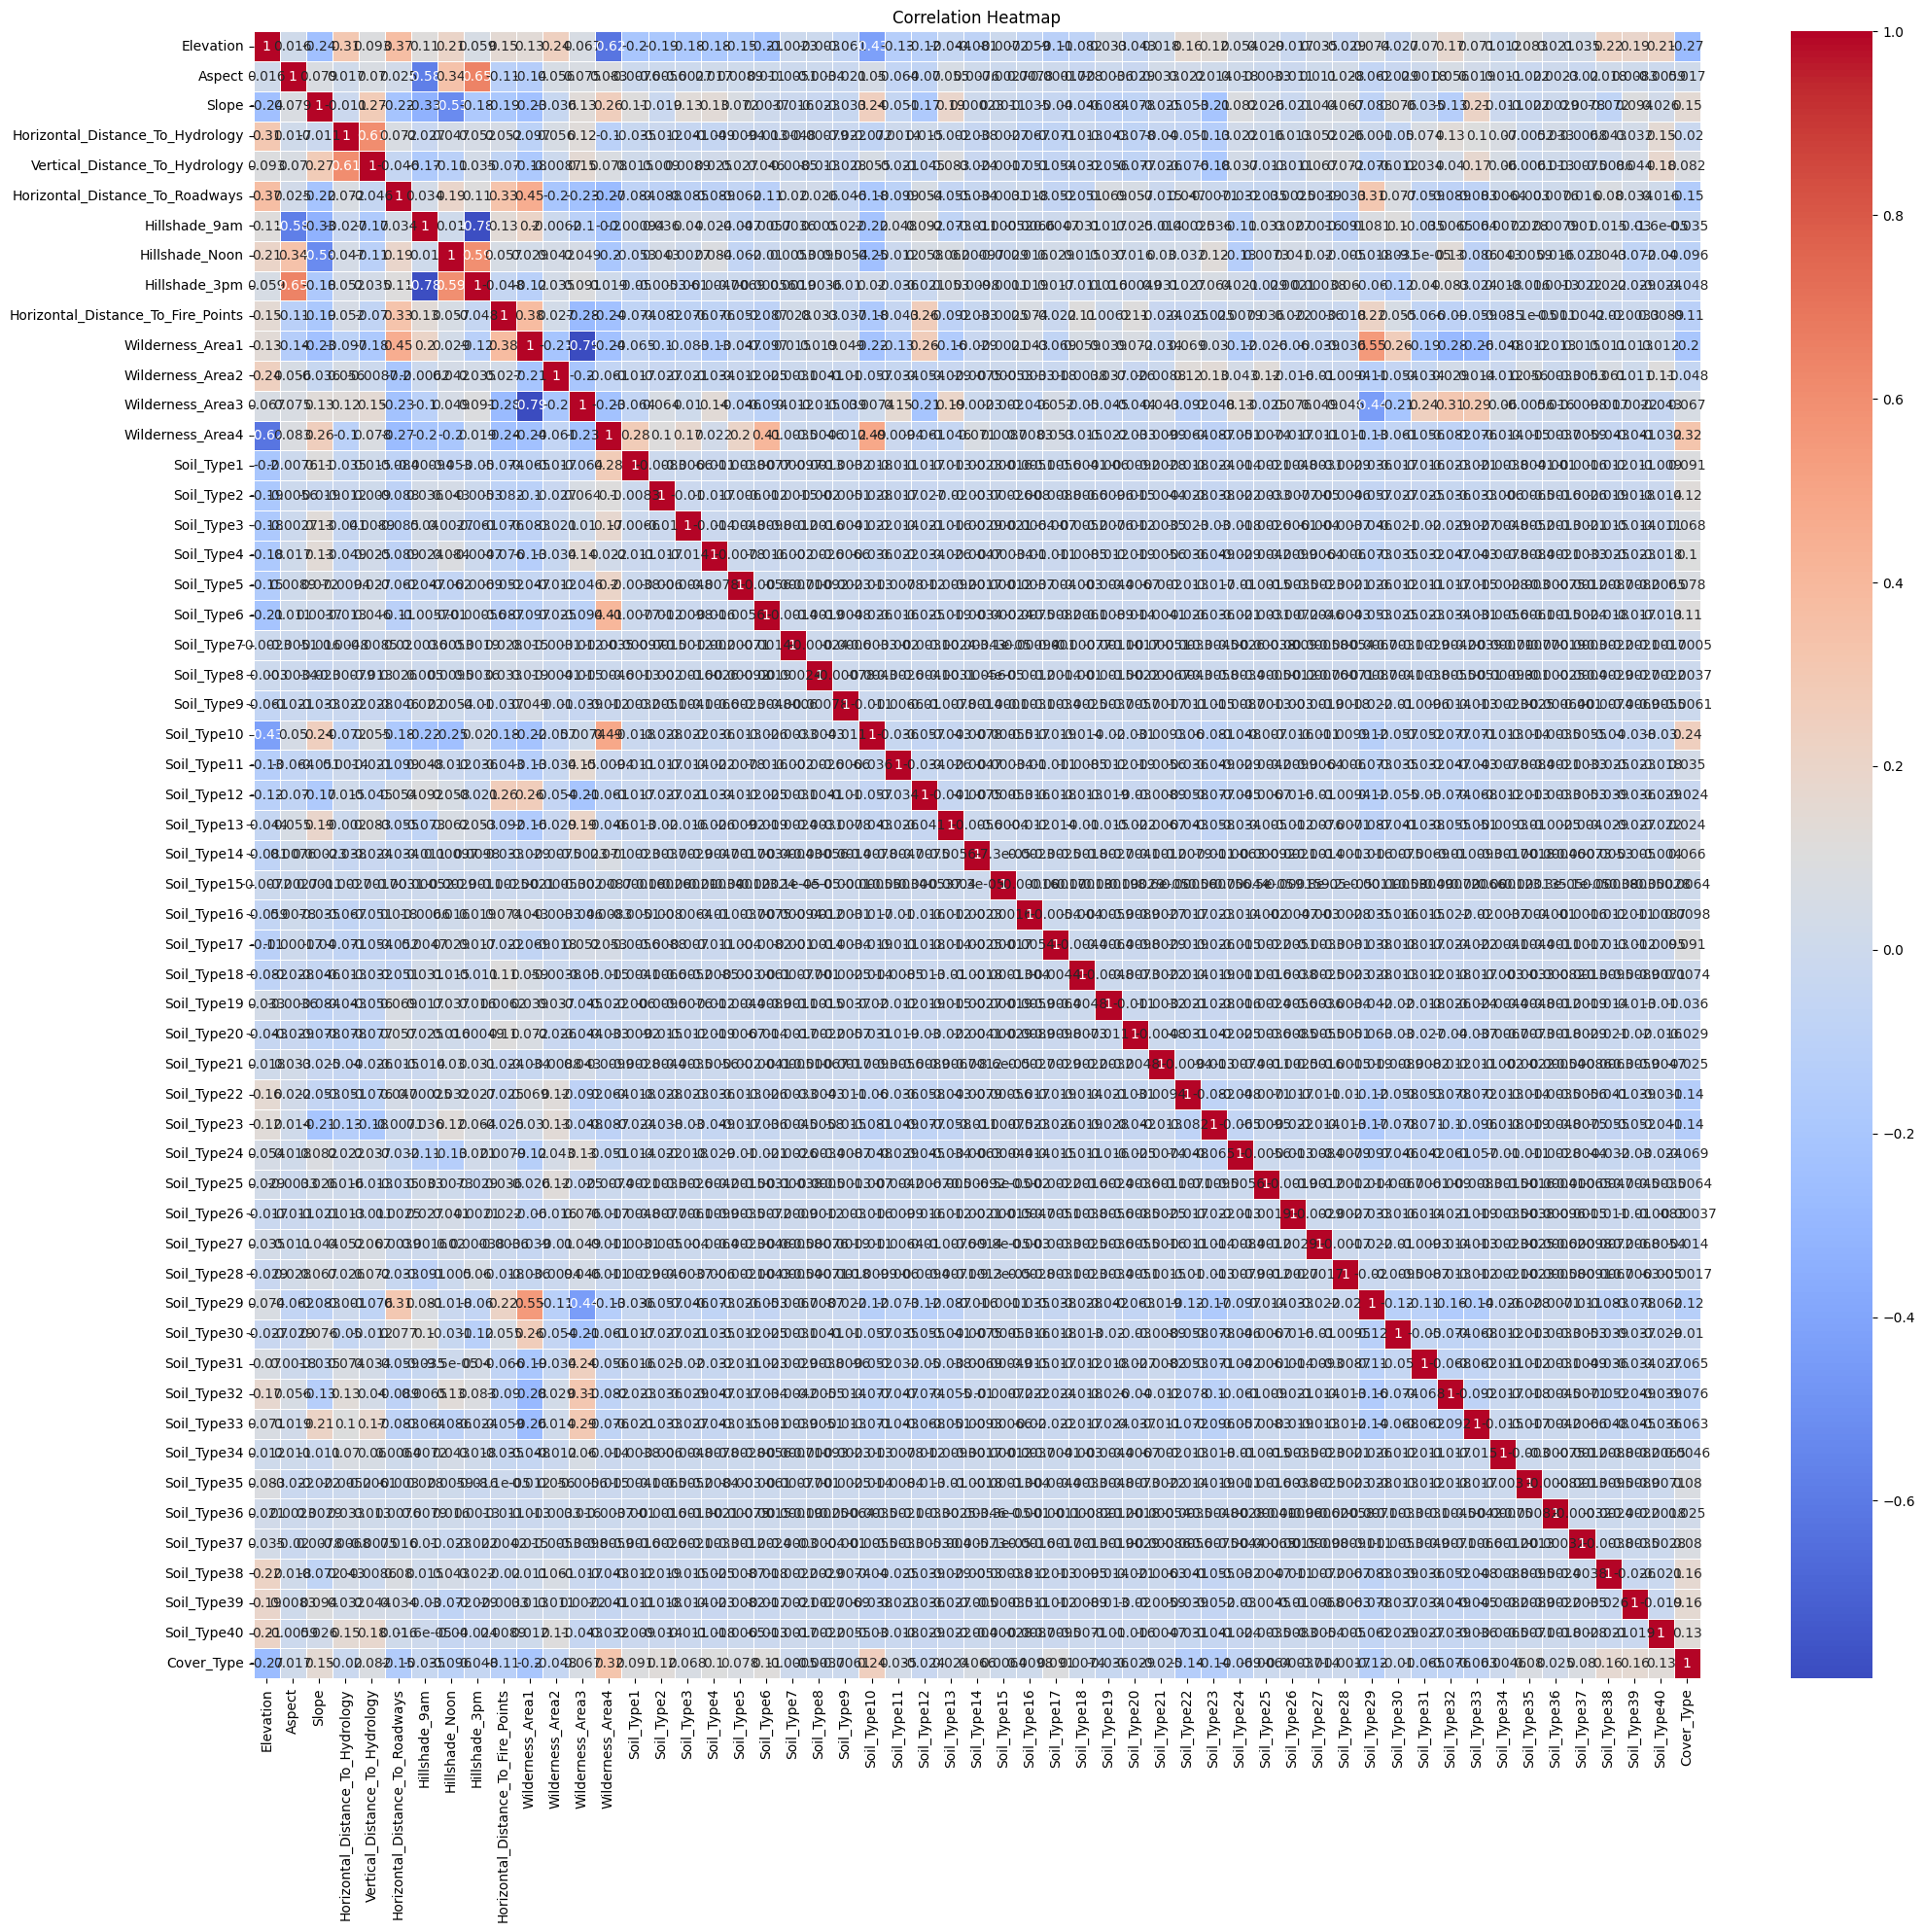

In [11]:
# Heat Map checking on the corellation values
corr_matrix = fct.corr(numeric_only=True)
plt.figure(figsize=(24, 22))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

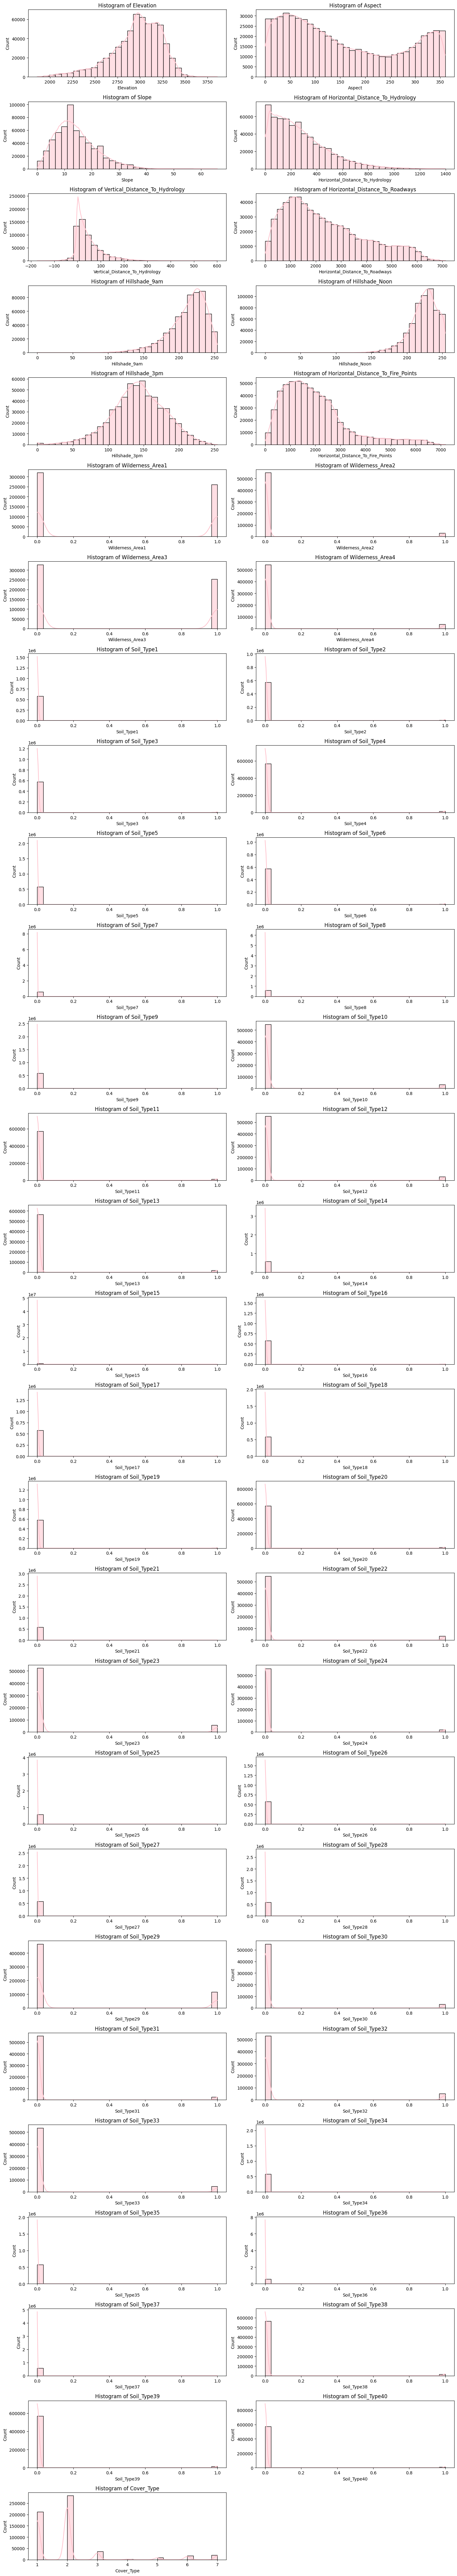

In [12]:
# Using histogram/bar graph visualization
cols = fct.columns
n_features = len(cols)

# Calculate the number of rows needed based on the number of features and columns per row
n_cols_per_row = 2
n_rows = (n_features + n_cols_per_row - 1) // n_cols_per_row # Use integer division and ceiling

fig, axes = plt.subplots(n_rows, n_cols_per_row, figsize=(15, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(fct[col], bins=30, kde=True, ax=axes[i], color="pink")
    axes[i].set_title(f"Histogram of {col}")

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

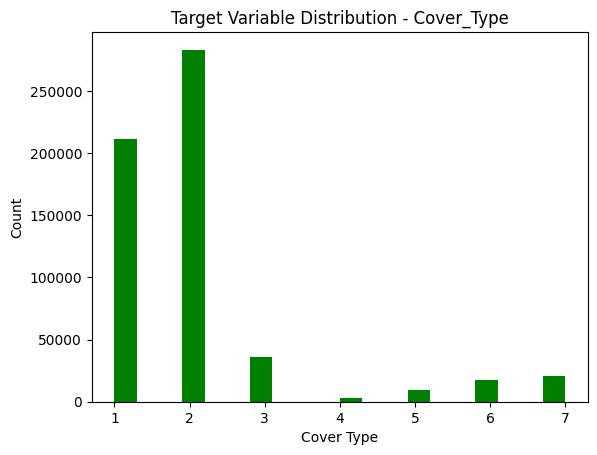

In [13]:
# Visualize focus on target variable using histogram plot
target_var = fct['Cover_Type'].dropna()

plt.figure()
plt.hist(target_var, bins=20, color='green')
plt.title('Target Variable Distribution - Cover_Type')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

According to the plot, there is an **extreme class imbalance** appear!!

In [14]:
# check and rank the values count for each target variable
fct['Cover_Type'].value_counts()

,count
Cover_Type,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747


Wilderness_Area 1 counts:
Wilderness_Area1
0    320216
1    260796
Name: count, dtype: int64


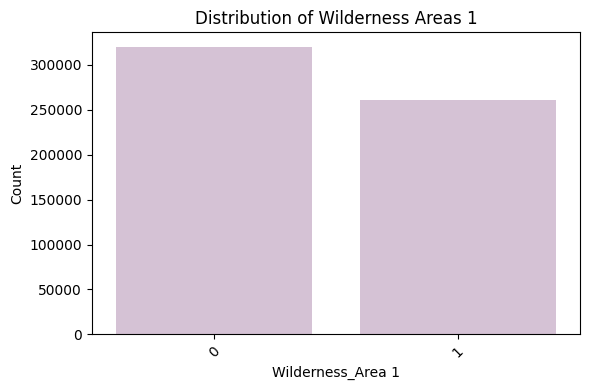


Wilderness_Area 2 counts:
Wilderness_Area2
0    551128
1     29884
Name: count, dtype: int64


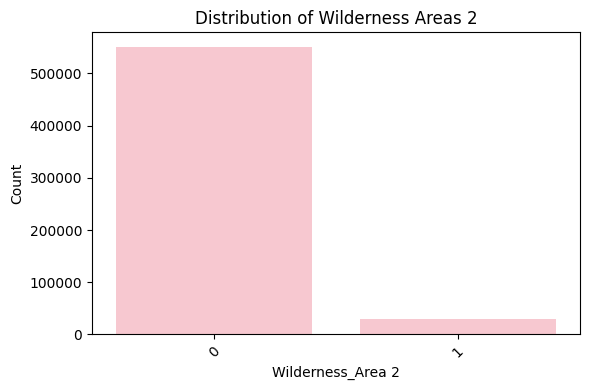


Wilderness_Area 3 counts:
Wilderness_Area3
0    327648
1    253364
Name: count, dtype: int64


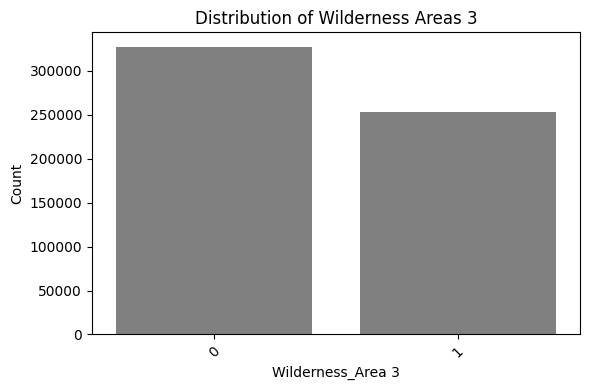


Wilderness_Area 4 counts:
Wilderness_Area4
0    544044
1     36968
Name: count, dtype: int64


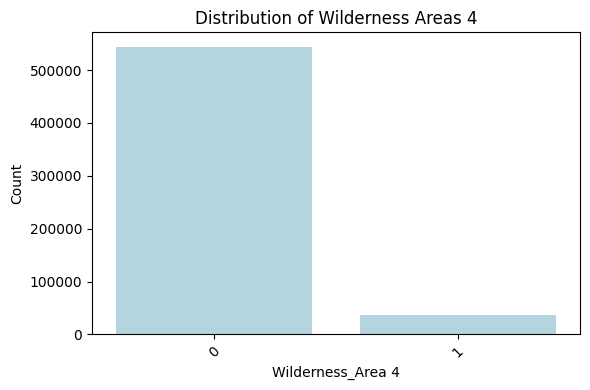

In [15]:
## CHECK FOR DISTRIBUTION OF TARGET VARIABLE IN EACH WILDERNESS AREA
# Distribution for Wilderness Area 1
if "Wilderness_Area1" in fct.columns:
    wild_counts = fct["Wilderness_Area1"].value_counts()
    print("Wilderness_Area 1 counts:")
    print(wild_counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x="Wilderness_Area1", data=fct, color='thistle')
    plt.title("Distribution of Wilderness Areas 1")
    plt.xlabel("Wilderness_Area 1")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Wilderness_Area 1' not found – adjust if your dataset uses dummy columns like Wilderness_Area1–4.")

# Distribution for Wilderness Area 2
if "Wilderness_Area2" in fct.columns:
    wild_counts = fct["Wilderness_Area2"].value_counts()
    print("\nWilderness_Area 2 counts:")
    print(wild_counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x="Wilderness_Area2", data=fct, color='pink')
    plt.title("Distribution of Wilderness Areas 2")
    plt.xlabel("Wilderness_Area 2")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Wilderness_Area 2' not found!")

# Distribution for Wilderness Area 3
if "Wilderness_Area3" in fct.columns:
    wild_counts = fct["Wilderness_Area3"].value_counts()
    print("\nWilderness_Area 3 counts:")
    print(wild_counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x="Wilderness_Area3", data=fct, color='grey')
    plt.title("Distribution of Wilderness Areas 3")
    plt.xlabel("Wilderness_Area 3")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Wilderness_Area 3' not found!")

# Distribution for Wilderness Area 4
if "Wilderness_Area4" in fct.columns:
    wild_counts = fct["Wilderness_Area4"].value_counts()
    print("\nWilderness_Area 4 counts:")
    print(wild_counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x="Wilderness_Area4", data=fct, color='lightblue')
    plt.title("Distribution of Wilderness Areas 4")
    plt.xlabel("Wilderness_Area 4")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Wilderness_Area 4' not found!")

Proportion of each tree type within each wilderness area:
Cover_Type               1         2         3         4         5         6  \
Wilderness_Area                                                                
Wilderness_Area1  0.405363  0.560580  0.000000  0.000000  0.014498  0.000000   
Wilderness_Area2  0.622239  0.300663  0.000000  0.000000  0.000000  0.000000   
Wilderness_Area3  0.345463  0.493728  0.056441  0.000000  0.022545  0.030099   
Wilderness_Area4  0.000000  0.081855  0.580340  0.074308  0.000000  0.263498   

Cover_Type               7  
Wilderness_Area             
Wilderness_Area1  0.019559  
Wilderness_Area2  0.077098  
Wilderness_Area3  0.051724  
Wilderness_Area4  0.000000  


<Figure size 800x500 with 0 Axes>

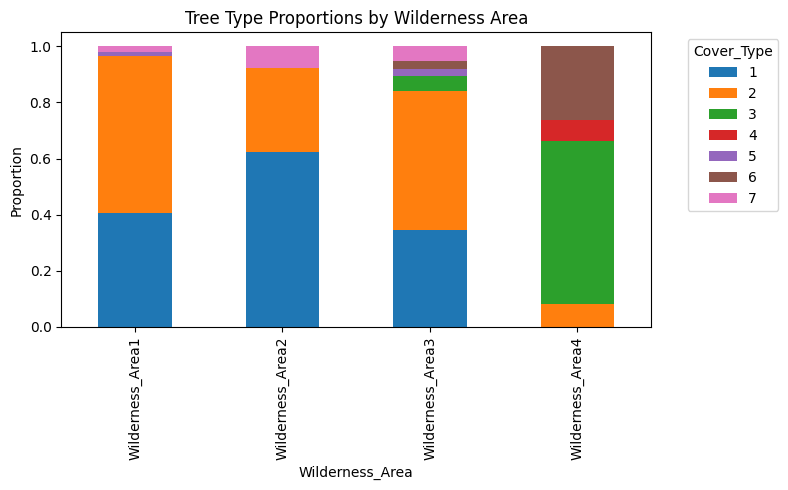

In [16]:
# DISTRIBUTION OF EACH TREE TYPE IN A SPECIFIC WILDERNESS AREA
# Identify wilderness dummy columns
wilderness_cols = ["Wilderness_Area1", "Wilderness_Area2", "Wilderness_Area3", "Wilderness_Area4"]

# Convert dummy columns to single categorical column
fct["Wilderness_Area"] = fct[wilderness_cols].idxmax(axis=1)

# Tree Type vs Wilderness
if "Cover_Type" in fct.columns and "Wilderness_Area" in fct.columns:
    ctab = pd.crosstab(fct["Wilderness_Area"], fct["Cover_Type"], normalize="index")
    print("Proportion of each tree type within each wilderness area:")
    print(ctab)

    plt.figure(figsize=(8, 5))
    ctab.plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title("Tree Type Proportions by Wilderness Area")
    plt.xlabel("Wilderness_Area")
    plt.ylabel("Proportion")
    plt.legend(title="Cover_Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Need both 'Cover_Type' and 'Wilderness_Area' columns for this step.")

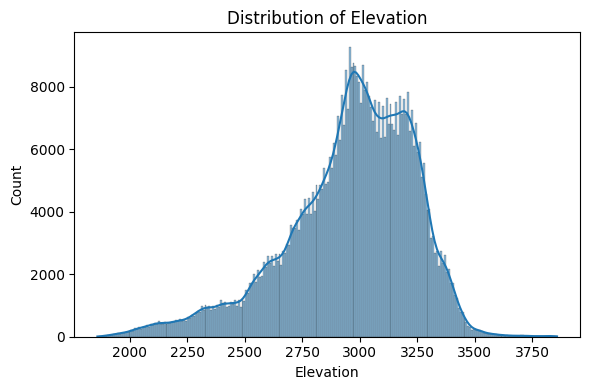

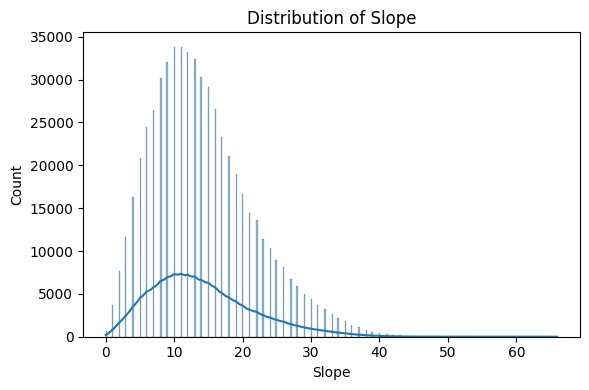

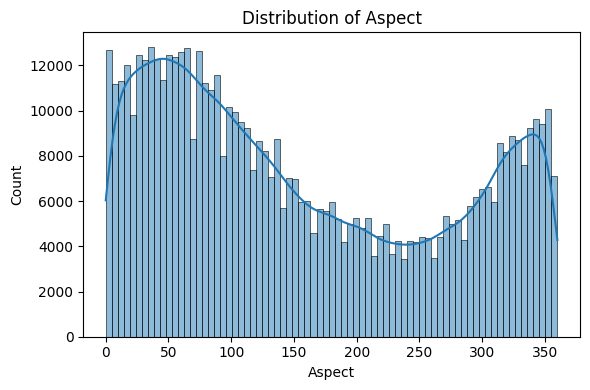

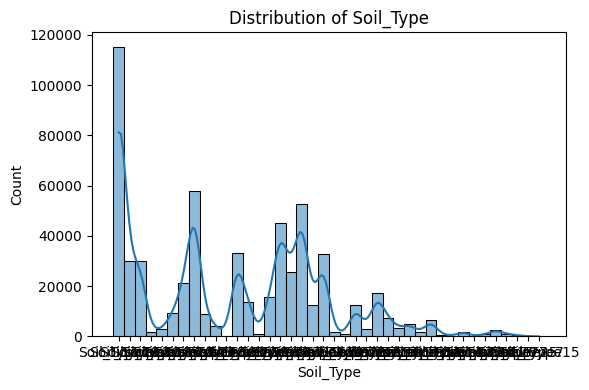

In [17]:
# DISTRIBUTION OF CORELLATED VARIABLES
# identify Soil_Type dummy columns
soil_cols = ['Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40']

# Convert dummy columns to single categorical column
fct["Soil_Type"] = fct[soil_cols].idxmax(axis=1)

# Choose correlated numeric feature columns to visualize
num_cols = ["Elevation", "Slope", "Aspect", "Soil_Type"]

for col in num_cols:
    if col in fct.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(fct[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found, skip or rename appropriately.")

## 3. Train Validation Test----------------------------------------------------------

In [18]:
# import the libraries
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold

In [19]:
# Train-Val-Test 60/20/20
# splitting data target and feature variables
fct_cleaned = fct.dropna(subset=['Cover_Type'])

# Drop the string-based 'Wilderness_Area' and 'Soil_Type' columns
cols_to_drop = ['Wilderness_Area', 'Soil_Type']
fct_cleaned = fct_cleaned.drop(columns=[col for col in cols_to_drop if col in fct_cleaned.columns])

X = fct_cleaned.drop('Cover_Type', axis=1)
y = fct_cleaned['Cover_Type']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val, random_state=42
)

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (348606, 54)
Val: (116203, 54)
Test: (116203, 54)


In [20]:
# Preprocessing
cat_cols = []  # ["Wilderness_Area", "Soil_Type"] in case they are categorical columns
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = "f1_macro" # more suitable for imbalanced multiclass

## 4. Preprocessing----------------------------------------

### Preprocessing for future final conclusion

In [21]:
# import neccessary libraries
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [22]:
# Help/support functions
def eval_on_val(model_name, fitted_estimator, X_val, y_val):
    """Return validation metrics in a dict."""
    pred = fitted_estimator.predict(X_val)
    return {
        "Model": model_name,
        "Val_Accuracy": accuracy_score(y_val, pred),
        "Val_BalancedAcc": balanced_accuracy_score(y_val, pred),
        "Val_F1_Macro": f1_score(y_val, pred, average="macro")
    }

def print_final_reports(best_name, best_model, X_val, y_val, X_test, y_test):
    print("\n" + "="*70)
    print(f"BEST MODEL: {best_name}")
    print("="*70)

    # Validation
    val_pred = best_model.predict(X_val)
    print("\n[VALIDATION] Classification Report")
    print(classification_report(y_val, val_pred))
    print("[VALIDATION] Confusion Matrix")
    print(confusion_matrix(y_val, val_pred))

    # Test (ONLY ONCE, at the end)
    test_pred = best_model.predict(X_test)
    print("\n[TEST] Classification Report")
    print(classification_report(y_test, test_pred))
    print("[TEST] Confusion Matrix")
    print(confusion_matrix(y_test, test_pred))

# store best estimator from each branch
results = []
fitted_models = {}

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Convert X_train.columns to a list to avoid potential issues with ColumnTransformer accepting a pandas Index object
numeric_features = list(X_train.columns)   # ALL columns are numeric

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

## 5. Baseline Models before Class Imbalance Handling-------------------------------------

DECISION TREE

In [24]:
# Create Pipeline for decision tree
dt_p = Pipeline([
    ("preprocess", preprocess),
    ("dtclf", DecisionTreeClassifier(random_state=42))
])

# Create Gridsearch
dt_grid = GridSearchCV(
    dt_p,
    param_grid={
        "dtclf__max_depth": [None, 10, 20],
        "dtclf__min_samples_split": [2, 5, 10]
    },
    scoring=scoring, cv=cv, n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
val_scores = [] # Initialize val_scores

# load decision tree model without SMOTE
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_val_pred = dt_best.predict(X_val)

# classification
print('Decision Tree Accuracy:', accuracy_score(y_val, y_val_pred))
print('Classification Report:')
print(classification_report(y_val, y_val_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, y_val_pred))

Decision Tree Accuracy: 0.930165314148516
Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.93      0.93     42368
           2       0.94      0.94      0.94     56660
           3       0.91      0.92      0.92      7151
           4       0.82      0.83      0.82       549
           5       0.79      0.82      0.81      1899
           6       0.86      0.84      0.85      3474
           7       0.94      0.95      0.94      4102

    accuracy                           0.93    116203
   macro avg       0.88      0.89      0.89    116203
weighted avg       0.93      0.93      0.93    116203


Confusion Matrix:
[[39367  2745     3     0    44     7   202]
 [ 2649 53306   199     1   331   136    38]
 [    3   164  6583    68    25   307     1]
 [    0     0    73   454     0    22     0]
 [   43   268    23     0  1559     6     0]
 [   11   134   351    32    11  2935     0]
 [  202    15     0     0     1     0  3884]]


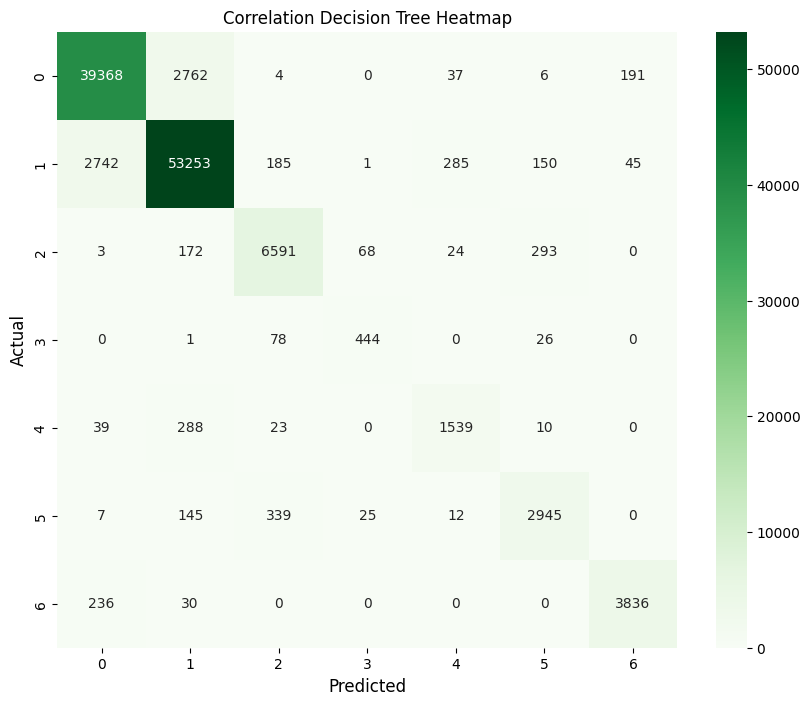

In [25]:
# visualize decision tree model correlation using heatmap
dt_y_pred = dt_best.predict(X_test)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, dt_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Decision Tree Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

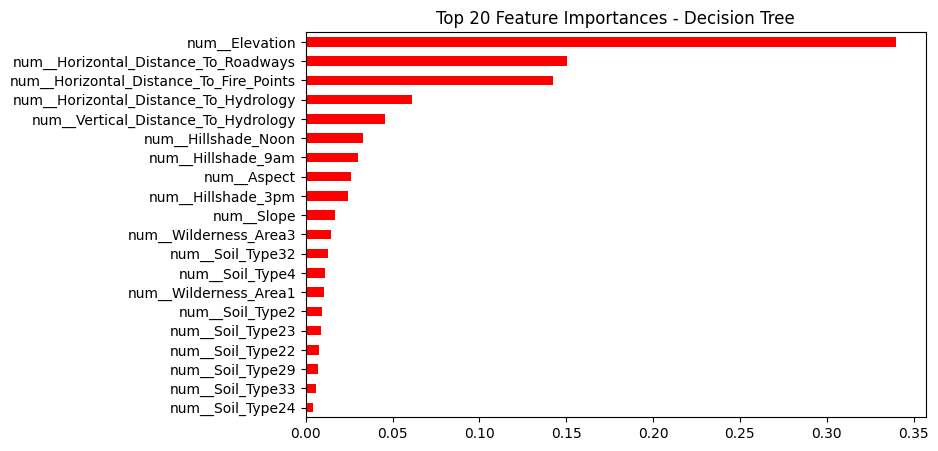

In [26]:
# Feature Importance
importances = dt_best.named_steps['dtclf'].feature_importances_
feat_names = dt_best.named_steps['preprocess'].get_feature_names_out()

fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)
fi.head(20).plot(kind='barh', figsize=(8,5), color='red')
plt.title("Top 20 Feature Importances - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

RANDOM FOREST

In [27]:
# create pipeline
rf_base = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(random_state=42))
])

rf_grid = GridSearchCV(
    rf_base,
    param_grid={
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [None, 10, 20]
    },
    scoring=scoring, cv=cv, n_jobs=1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_val_scores = [] # Initialize val_scores

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [28]:
# load random forest model without SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_best.predict(X_val)

# Classification
print('Random Forest Accuracy:', accuracy_score(y_val, rf_y_pred))
print('Classification Report:')
print(classification_report(y_val, rf_y_pred))

# Confusion Matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, rf_y_pred))

Random Forest Accuracy: 0.9483317986626851
Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.93      0.95     42368
           2       0.94      0.97      0.96     56660
           3       0.93      0.96      0.95      7151
           4       0.91      0.85      0.88       549
           5       0.92      0.76      0.83      1899
           6       0.92      0.89      0.90      3474
           7       0.97      0.94      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.90      0.92    116203
weighted avg       0.95      0.95      0.95    116203


Confusion Matrix:
[[39552  2709     2     0    12     9    84]
 [ 1377 54957   131     1   101    73    20]
 [    1   111  6848    28     5   158     0]
 [    0     0    66   465     0    18     0]
 [   27   404    29     0  1435     4     0]
 [    6   103   257    18     4  3086     0]
 [  228    17     0     0     1     0  3856]]


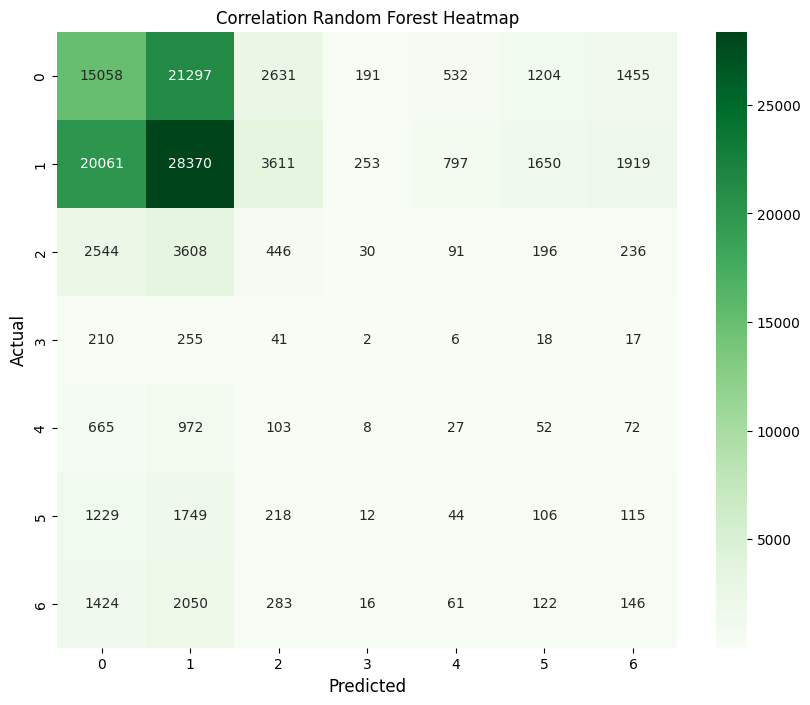

In [29]:
# visualize random forest model correlation using heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, rf_y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Correlation Random Forest Heatmap', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

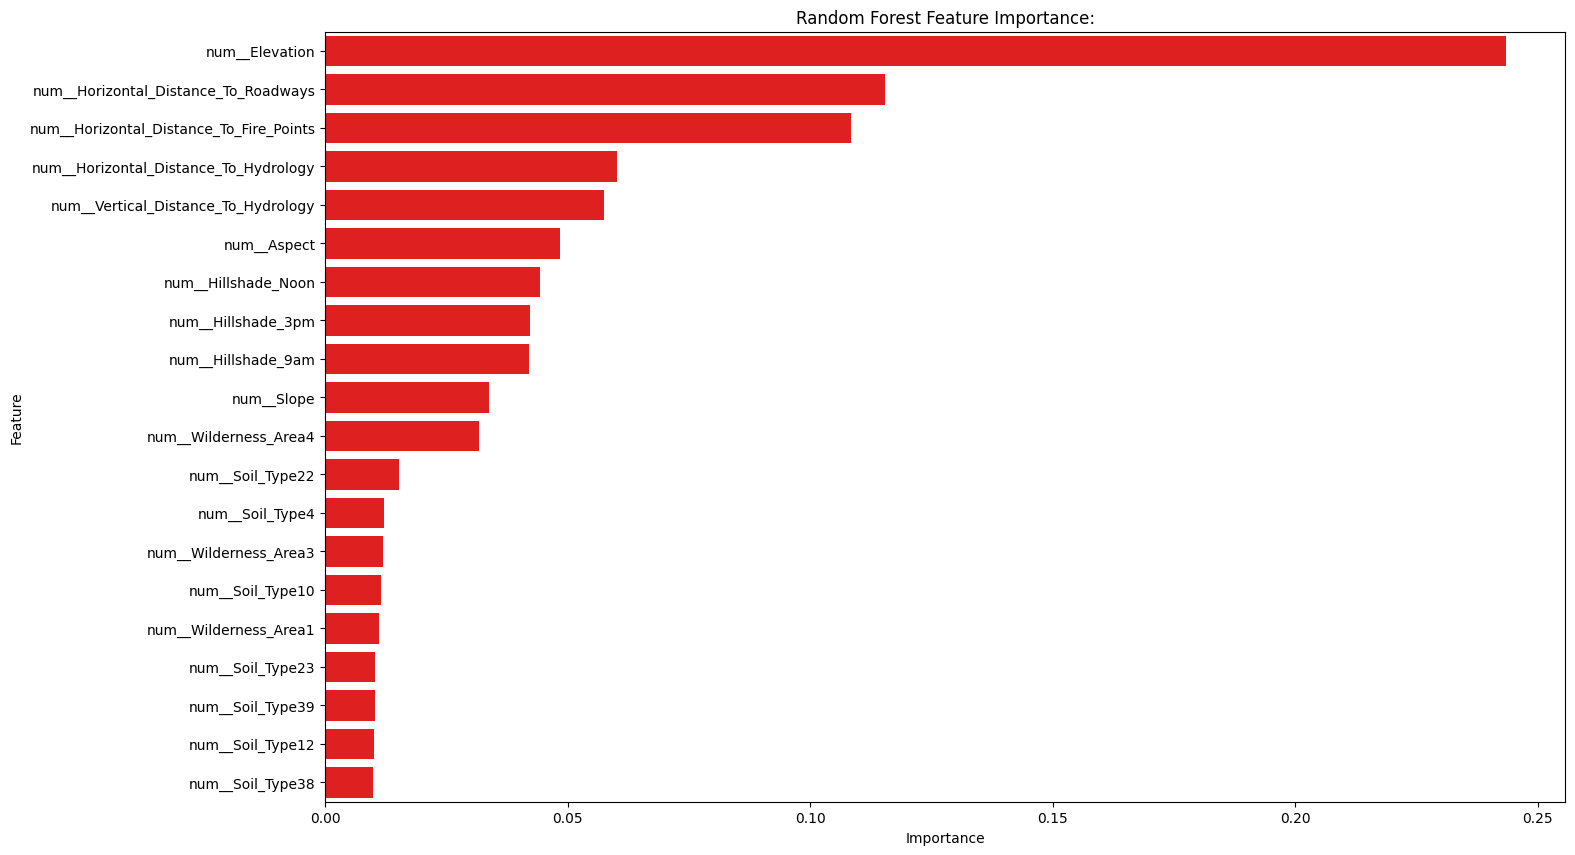

In [30]:
# Feature Importance of Random Forest Model
importances = rf_best.named_steps['clf'].feature_importances_
feat_names = rf_best.named_steps['prep'].get_feature_names_out()

fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(16, 10))
sns.barplot(x=fi.head(20).values, y=fi.head(20).index, color='red')
plt.title('Random Forest Feature Importance:')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

XGBOOST

In [31]:
num_classes = y.nunique()

# Adjust target variable to be zero-indexed for XGBoost
y_train_adjusted = y_train - 1
y_val_adjusted = y_val - 1

xgb_base = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    ))
])
xgb_base_grid = GridSearchCV(
    xgb_base,
    param_grid={
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [4, 6, 8],
        "clf__learning_rate": [0.05, 0.1]
    },
    scoring=scoring, cv=cv, n_jobs=-1
)
xgb_base_grid.fit(X_train, y_train_adjusted) # Use adjusted y_train
xgb_base_best = xgb_base_grid.best_estimator_
# val_scores.append(("XGB (baseline)", evaluate_split("XGB (baseline) — VALIDATION", xgb_base_best, X_val, y_val)))

In [32]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

w_train = compute_sample_weight(class_weight="balanced", y=y_train_adjusted)

xgb_w = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=num_classes,
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42
    ))
])

xgb_w_grid = GridSearchCV(
    xgb_w,
    param_grid={
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [4, 6, 8],
        "clf__learning_rate": [0.05, 0.1]
    },
    scoring="f1_macro", cv=cv, n_jobs=-1
)

# Some sklearn versions don’t pass sample_weight through GridSearchCV
# apply estimator use!
try:
    xgb_w_grid.fit(X_train, y_train_adjusted, **{"clf__sample_weight": w_train})
    xgb_w_best = xgb_w_grid.best_estimator_
except TypeError:
    # fit grid without weights, then refit best with weights
    xgb_w_grid.fit(X_train, y_train_adjusted)
    xgb_w_best = xgb_w_grid.best_estimator_
    xgb_w_best.fit(X_train, y_train_adjusted, **{"clf__sample_weight": w_train})

# Validation evaluation
y_val_pred_adjusted = xgb_w_best.predict(X_val)
# Convert predictions back to original class labels 1-7 for evaluation against original y_val
y_val_pred = y_val_pred_adjusted + 1

print("\nXGB (weighted) — VALIDATION ONLY")
print(classification_report(y_val, y_val_pred, digits=3))
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred))


XGB (weighted) — VALIDATION ONLY
              precision    recall  f1-score   support

           1      0.910     0.919     0.915     42368
           2      0.942     0.911     0.926     56660
           3      0.940     0.957     0.948      7151
           4      0.885     0.927     0.906       549
           5      0.694     0.953     0.803      1899
           6      0.864     0.953     0.906      3474
           7      0.935     0.985     0.959      4102

    accuracy                          0.921    116203
   macro avg      0.881     0.943     0.909    116203
weighted avg      0.923     0.921     0.922    116203

Accuracy: 0.9213359379706204
Confusion Matrix:
 [[38930  3080     2     0   111    15   230]
 [ 3775 51622   273     1   665   272    52]
 [    0    32  6841    44    16   218     0]
 [    0     0    28   509     0    12     0]
 [    3    64    18     0  1809     5     0]
 [    3    17   118    21     6  3309     0]
 [   53     6     0     0     1     0  4042]]


In [33]:
# XGBOOST MODEL
# y predict for xgboost
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train_adjusted)
xgb_y_pred = xgb.predict(X_test)
xgb_y_pred = xgb_y_pred + 1
print(np.unique(xgb_y_pred))

# classification
print('\nXGBoost Accuracy:', accuracy_score(y_val, xgb_y_pred))
print('Classification Report:')
print(classification_report(y_val, xgb_y_pred))

# confusion matrix
print('\nConfusion Matrix:')
print(confusion_matrix(y_val, xgb_y_pred))

[1 2 3 4 5 6 7]

XGBoost Accuracy: 0.3816338648744008
Classification Report:
              precision    recall  f1-score   support

           1       0.37      0.35      0.36     42368
           2       0.49      0.50      0.50     56660
           3       0.06      0.06      0.06      7151
           4       0.00      0.00      0.00       549
           5       0.02      0.01      0.02      1899
           6       0.03      0.03      0.03      3474
           7       0.04      0.04      0.04      4102

    accuracy                           0.38    116203
   macro avg       0.14      0.14      0.14    116203
weighted avg       0.38      0.38      0.38    116203


Confusion Matrix:
[[15027 21372  2674   208   489  1221  1377]
 [20083 28579  3525   237   653  1623  1960]
 [ 2459  3633   463    38    82   206   270]
 [  181   293    39     0     5     7    24]
 [  655   959   115     9    28    56    77]
 [ 1222  1789   198    21    29   101   114]
 [ 1451  2072   247    19    51   113

# 6. Class Imbalance Handling-----------------------------------

In [43]:
# Import all neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_sample_weight
# imbalanced-learn
from imblearn.pipeline import Pipeline          # imblearn Pipeline supports SMOTE inside CV
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
# XGBoost
from xgboost import XGBClassifier

In [44]:
# Setup shared config
# StratifiedKFold for all models because target is imbalanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = 'f1_macro'   # macro F1 is best for imbalanced multiclass
RANDOM_STATE = 42

print('All imports successful.')

All imports successful.


# CLASS IMBALANCE HANDLING - SMOTE

In [49]:
# Helper for evaluate on validation set
def evaluate(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    print(f'\n=== {name} ===')
    print(classification_report(y_eval, y_pred, digits=3))
    print(f'Accuracy : {accuracy_score(y_eval, y_pred):.4f}')
    print(f'F1 Macro : {f1_score(y_eval, y_pred, average="macro"):.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_eval, y_pred))
    return f1_score(y_eval, y_pred, average='macro')

DECISION TREE

In [51]:
# SMOTE WITH DECISION TREE
smote_dt_pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

smote_dt_params = {
    'smote__k_neighbors': [3, 5],
    'clf__max_depth': [10, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced']
}

smote_dt_search = RandomizedSearchCV(
    smote_dt_pipe,
    param_distributions=smote_dt_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_dt_search.fit(X_train, y_train)
smote_dt_best = smote_dt_search.best_estimator_

print('Best params (SMOTE + DT):', smote_dt_search.best_params_)
print(f'Best CV F1 Macro: {smote_dt_search.best_score_:.4f}')
evaluate('SMOTE + Decision Tree — VALIDATION', smote_dt_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params (SMOTE + DT): {'smote__k_neighbors': 5, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 2, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}
Best CV F1 Macro: 0.8808

=== SMOTE + Decision Tree — VALIDATION ===
              precision    recall  f1-score   support

           1      0.921     0.937     0.929     42368
           2      0.950     0.927     0.939     56660
           3      0.916     0.932     0.924      7151
           4      0.838     0.878     0.858       549
           5      0.764     0.858     0.808      1899
           6      0.843     0.872     0.857      3474
           7      0.928     0.957     0.942      4102

    accuracy                          0.929    116203
   macro avg      0.880     0.909     0.894    116203
weighted avg      0.930     0.929     0.929    116203

Accuracy : 0.9290
F1 Macro : 0.8938
Confusion Matrix:
[[39693  2319     5    

0.8937959270498271

RANDOM FOREST

In [52]:
# SMOTE WITH RANDOM FOREST
# pipeline setup
smote_rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

smote_rf_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2']
}

# tuning by RandomizedSearchCV and StratifiedKFold (with cross validation)
smote_rf_search = RandomizedSearchCV(
    smote_rf_pipe,
    param_distributions=smote_rf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_rf_search.fit(X_train, y_train)
smote_rf_best = smote_rf_search.best_estimator_

print('Best params (SMOTE with RF):', smote_rf_search.best_params_)
print(f'Best CV F1 Macro: {smote_rf_search.best_score_:.4f}')
evaluate('SMOTE + Random Forest — VALIDATION', smote_rf_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (SMOTE with RF): {'smote__k_neighbors': 3, 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.9209

=== SMOTE + Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.959     0.941     0.950     42368
           2      0.955     0.959     0.957     56660
           3      0.937     0.958     0.947      7151
           4      0.881     0.907     0.894       549
           5      0.841     0.891     0.865      1899
           6      0.879     0.927     0.902      3474
           7      0.956     0.970     0.963      4102

    accuracy                          0.951    116203
   macro avg      0.916     0.936     0.926    116203
weighted avg      0.951     0.951     0.951    116203

Accuracy : 0.9507
F1 Macro : 0.9256
Confusion Matrix:
[[39883  2281     5     0    41    16   142]
 [ 1579 54359   208     1   261   211    41]

0.9256022819128406

XGBOOST

In [53]:
# SMOTE WITH XGBOOST
y_train_adj = y_train - 1
y_val_adj   = y_val   - 1
num_classes = len(np.unique(y_train_adj))

# setup pipeline
smote_xgb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

smote_xgb_params = {
    'smote__k_neighbors': [3, 5],
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0]
}

# tuning with RandomizedSearchCV and StratifiedKFold
smote_xgb_search = RandomizedSearchCV(
    smote_xgb_pipe,
    param_distributions=smote_xgb_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

smote_xgb_search.fit(X_train, y_train_adj)
smote_xgb_best = smote_xgb_search.best_estimator_

print('Best params (SMOTE with XGB):', smote_xgb_search.best_params_)
print(f'Best CV F1 Macro: {smote_xgb_search.best_score_:.4f}')

# Convert predictions back to original labels 1-7
y_val_pred_xgb = smote_xgb_best.predict(X_val) + 1
print('\nSMOTE + XGBoost — VALIDATION')
print(classification_report(y_val, y_val_pred_xgb, digits=3))
print(f'Accuracy : {accuracy_score(y_val, y_val_pred_xgb):.4f}')
print(f'F1 Macro : {f1_score(y_val, y_val_pred_xgb, average="macro"):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (SMOTE with XGB): {'smote__k_neighbors': 3, 'clf__subsample': 0.7, 'clf__n_estimators': 300, 'clf__max_depth': 8, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 1.0}
Best CV F1 Macro: 0.9230

SMOTE + XGBoost — VALIDATION
              precision    recall  f1-score   support

           1      0.941     0.925     0.933     42368
           2      0.944     0.946     0.945     56660
           3      0.950     0.955     0.953      7151
           4      0.867     0.923     0.894       549
           5      0.810     0.907     0.856      1899
           6      0.896     0.943     0.919      3474
           7      0.954     0.977     0.965      4102

    accuracy                          0.939    116203
   macro avg      0.909     0.939     0.923    116203
weighted avg      0.939     0.939     0.939    116203

Accuracy : 0.9391
F1 Macro : 0.9235


# CLASS IMBALANCE HANDLING - BALANCED RANDOM FOREST

In [54]:
# Because BalancedRandomForestClassifier does NOT need SMOTE inside Pipeline
# So I'll handle imbalance internally
from sklearn.pipeline import Pipeline as SkPipeline  # use sklearn Pipeline (for no SMOTE step)

# setup pipeline
brf_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', BalancedRandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

brf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2'],
    'clf__sampling_strategy': ['auto', 'not majority']
}

# using RandomizedSearchCV for tuning
brf_search = RandomizedSearchCV(
    brf_pipe,
    param_distributions=brf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

brf_search.fit(X_train, y_train)
brf_best = brf_search.best_estimator_

print('Best params (BRF):', brf_search.best_params_)
print(f'Best CV F1 Macro: {brf_search.best_score_:.4f}')
evaluate('Balanced Random Forest — VALIDATION', brf_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (BRF): {'clf__sampling_strategy': 'auto', 'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.7165

=== Balanced Random Forest — VALIDATION ===
              precision    recall  f1-score   support

           1      0.808     0.804     0.806     42368
           2      0.881     0.747     0.809     56660
           3      0.801     0.852     0.826      7151
           4      0.537     0.973     0.692       549
           5      0.316     0.968     0.476      1899
           6      0.573     0.897     0.699      3474
           7      0.649     0.980     0.781      4102

    accuracy                          0.792    116203
   macro avg      0.652     0.889     0.727    116203
weighted avg      0.822     0.792     0.799    116203

Accuracy : 0.7915
F1 Macro : 0.7270
Confusion Matrix:
[[34068  5632    11     0   674   106  1877]
 [ 7993 42311  1253    23  3251  1530   299]

0.7269621392152917

# CLASS IMBALANCE HANDLING - COST-SENSITIVE

DECISION TREE

In [55]:
from sklearn.pipeline import Pipeline as SkPipeline

# setup pipeline
# class_weight in this case
cs_dt_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

# using GridSearchCV for DT since it has small param grid
cs_dt_params = {
    'clf__max_depth': [10, 20, 30, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion': ['gini', 'entropy']
}

cs_dt_grid = GridSearchCV(
    cs_dt_pipe,
    param_grid=cs_dt_params,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

cs_dt_grid.fit(X_train, y_train)
cs_dt_best = cs_dt_grid.best_estimator_

print('Best params (Cost-Sensitive DT):', cs_dt_grid.best_params_)
print(f'Best CV F1 Macro: {cs_dt_grid.best_score_:.4f}')
evaluate('Cost-Sensitive DT — VALIDATION', cs_dt_best, X_val, y_val)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params (Cost-Sensitive DT): {'clf__criterion': 'entropy', 'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV F1 Macro: 0.8805

=== Cost-Sensitive DT — VALIDATION ===
              precision    recall  f1-score   support

           1      0.935     0.930     0.932     42368
           2      0.940     0.945     0.943     56660
           3      0.917     0.914     0.915      7151
           4      0.846     0.851     0.848       549
           5      0.831     0.807     0.819      1899
           6      0.856     0.854     0.855      3474
           7      0.946     0.943     0.945      4102

    accuracy                          0.932    116203
   macro avg      0.896     0.892     0.894    116203
weighted avg      0.932     0.932     0.932    116203

Accuracy : 0.9322
F1 Macro : 0.8938
Confusion Matrix:
[[39407  2710     7     0    39    13   192]
 [ 2492 53548   196     0   245  

0.8938486800216993

RANDOM FOREST

In [56]:
from sklearn.pipeline import Pipeline as SkPipeline

# setup pipeline
# class_weight in this case
cs_rf_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# using RandomizedSearchCV for tuning
cs_rf_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
    'clf__max_features': ['sqrt', 'log2']
}

cs_rf_search = RandomizedSearchCV(
    cs_rf_pipe,
    param_distributions=cs_rf_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

cs_rf_search.fit(X_train, y_train)
cs_rf_best = cs_rf_search.best_estimator_

print('Best params (Cost-Sensitive RF):', cs_rf_search.best_params_)
print(f'Best CV F1 Macro: {cs_rf_search.best_score_:.4f}')
evaluate('Cost-Sensitive RF — VALIDATION', cs_rf_best, X_val, y_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (Cost-Sensitive RF): {'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': None}
Best CV F1 Macro: 0.9102

=== Cost-Sensitive RF — VALIDATION ===
              precision    recall  f1-score   support

           1      0.962     0.935     0.948     42368
           2      0.943     0.971     0.957     56660
           3      0.933     0.957     0.945      7151
           4      0.905     0.851     0.877       549
           5      0.920     0.760     0.833      1899
           6      0.924     0.884     0.903      3474
           7      0.974     0.944     0.959      4102

    accuracy                          0.949    116203
   macro avg      0.937     0.900     0.917    116203
weighted avg      0.949     0.949     0.949    116203

Accuracy : 0.9492
F1 Macro : 0.9174
Confusion Matrix:
[[39599  2658     3     0    14     9    85]
 [ 1329 55003   132     0   105    74    17]
 [    2   115  6847    3

0.9173745087291386

XGBOOST

In [57]:
from sklearn.pipeline import Pipeline as SkPipeline

# compute sample weights from y_train (original labels 1-7)
w_train = compute_sample_weight(class_weight='balanced', y=y_train)

# setup pipeline
# sample_weight in this case
cs_xgb_pipe = SkPipeline([
    ('preprocess', preprocess),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

cs_xgb_params = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [4, 6, 8],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.8, 1.0],
    'clf__colsample_bytree': [0.7, 0.8, 1.0]
}

cs_xgb_search = RandomizedSearchCV(
    cs_xgb_pipe,
    param_distributions=cs_xgb_params,
    n_iter=20,
    scoring=SCORING,
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# pass sample_weight through Pipeline using clf__ prefix
try:
    cs_xgb_search.fit(X_train, y_train_adj, clf__sample_weight=w_train)
except TypeError:
    # Fallback to fit without weights then refit best estimator with weights
    cs_xgb_search.fit(X_train, y_train_adj)
    cs_xgb_search.best_estimator_.fit(X_train, y_train_adj, clf__sample_weight=w_train)

cs_xgb_best = cs_xgb_search.best_estimator_

print('Best params (Cost-Sensitive XGB):', cs_xgb_search.best_params_)
print(f'Best CV F1 Macro: {cs_xgb_search.best_score_:.4f}')

y_val_pred_cs_xgb = cs_xgb_best.predict(X_val) + 1
print('\nCost-Sensitive XGBoost — VALIDATION')
print(classification_report(y_val, y_val_pred_cs_xgb, digits=3))
print(f'Accuracy : {accuracy_score(y_val, y_val_pred_cs_xgb):.4f}')
print(f'F1 Macro : {f1_score(y_val, y_val_pred_cs_xgb, average="macro"):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (Cost-Sensitive XGB): {'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__max_depth': 8, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}
Best CV F1 Macro: 0.9143

Cost-Sensitive XGBoost — VALIDATION
              precision    recall  f1-score   support

           1      0.925     0.926     0.925     42368
           2      0.947     0.924     0.936     56660
           3      0.942     0.958     0.950      7151
           4      0.876     0.916     0.896       549
           5      0.712     0.952     0.814      1899
           6      0.869     0.952     0.908      3474
           7      0.945     0.983     0.964      4102

    accuracy                          0.930    116203
   macro avg      0.888     0.945     0.913    116203
weighted avg      0.932     0.930     0.931    116203

Accuracy : 0.9304
F1 Macro : 0.9133


# 7. Model Comparision - Validation F1 Macro--------------------------------------

                    F1_Macro_Val
SMOTE + RF              0.925602
Cost-Sensitive RF       0.917375
Cost-Sensitive DT       0.893849
SMOTE + DT              0.893796
Balanced RF             0.726962
Cost-Sensitive XGB      0.009171
SMOTE + XGB             0.007324


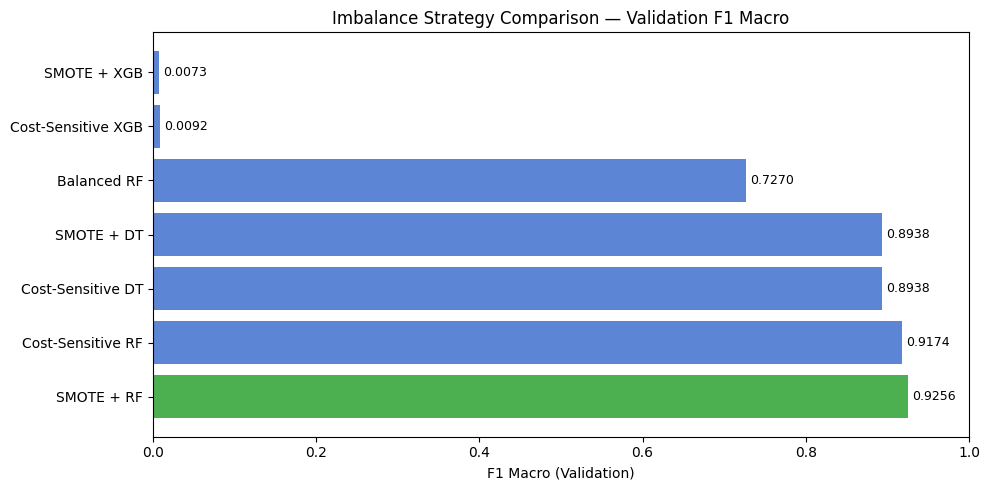


Best model: SMOTE + RF (F1 Macro = 0.9256)


In [58]:
# Collect validation F1 Macro scores
results = {}

# setup some helpers that helps handle XGB 0-indexed offset
def get_f1(model, X_eval, y_eval, offset=0):
    pred = model.predict(X_eval)
    if offset:
        pred = pred + offset
    return f1_score(y_eval, pred, average='macro')

results['SMOTE + DT']         = get_f1(smote_dt_best,  X_val, y_val)
results['SMOTE + RF']         = get_f1(smote_rf_best,  X_val, y_val)
results['SMOTE + XGB']        = get_f1(smote_xgb_best, X_val, y_val_adj, offset=1)
results['Balanced RF']        = get_f1(brf_best,        X_val, y_val)
results['Cost-Sensitive DT']  = get_f1(cs_dt_best,     X_val, y_val)
results['Cost-Sensitive XGB'] = get_f1(cs_xgb_best,    X_val, y_val_adj, offset=1)
results['Cost-Sensitive RF']  = get_f1(cs_rf_best,     X_val, y_val)

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1_Macro_Val'])
results_df = results_df.sort_values('F1_Macro_Val', ascending=False)
print(results_df.to_string())

# Bar chart visualization for Macro F1 Validation
plt.figure(figsize=(10, 5))
colors = ['#4CAF50' if v == results_df['F1_Macro_Val'].max() else '#5C85D6'
          for v in results_df['F1_Macro_Val']]
bars = plt.barh(results_df.index, results_df['F1_Macro_Val'], color=colors)
plt.xlabel('F1 Macro (Validation)')
plt.title('Imbalance Strategy Comparison — Validation F1 Macro')
plt.xlim(0, 1)
for bar, val in zip(bars, results_df['F1_Macro_Val']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_model_name = results_df.index[0]
print(f'\nBest model: {best_model_name} (F1 Macro = {results_df.iloc[0,0]:.4f})')

# 8. Final Test Evaluation for Best Model Only

 SMOTE + RF — FINAL TEST SET
              precision    recall  f1-score   support

           1      0.961     0.941     0.951     42368
           2      0.955     0.962     0.959     56661
           3      0.932     0.960     0.946      7151
           4      0.876     0.891     0.883       549
           5      0.874     0.897     0.885      1899
           6      0.888     0.922     0.905      3473
           7      0.951     0.966     0.959      4102

    accuracy                          0.952    116203
   macro avg      0.920     0.934     0.927    116203
weighted avg      0.952     0.952     0.952    116203

Accuracy : 0.9517
F1 Macro : 0.9267


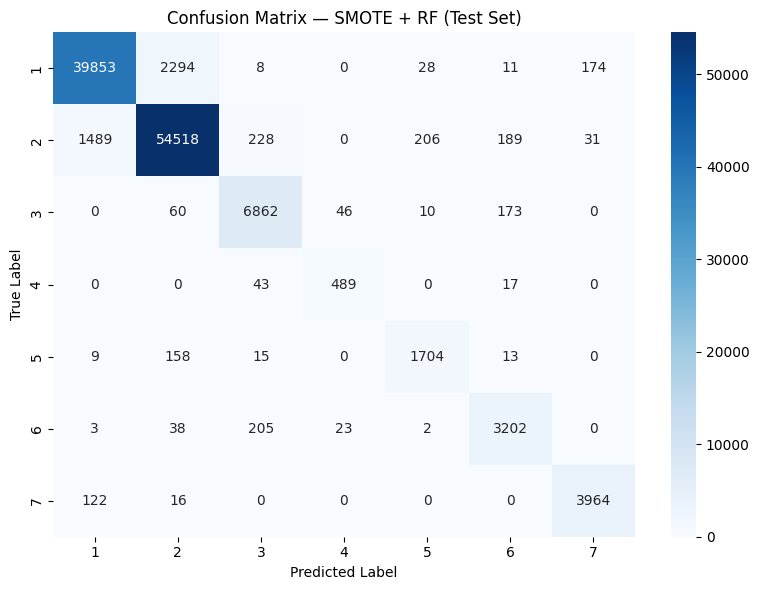

In [59]:
# Transfer map model name to estimator
model_map = {
    'SMOTE + DT':         (smote_dt_best,  0),
    'SMOTE + RF':         (smote_rf_best,  0),
    'SMOTE + XGB':        (smote_xgb_best, 1),
    'Balanced RF':        (brf_best,        0),
    'Cost-Sensitive DT':  (cs_dt_best,     0),
    'Cost-Sensitive XGB': (cs_xgb_best,    1),
    'Cost-Sensitive RF':  (cs_rf_best,     0)
}

best_est, offset = model_map[best_model_name]
y_test_input = y_test - 1 if offset else y_test

y_test_pred = best_est.predict(X_test)
if offset:
    y_test_pred = y_test_pred + 1

print(f' {best_model_name} — FINAL TEST SET')
print(classification_report(y_test, y_test_pred, digits=3))
print(f'Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'F1 Macro : {f1_score(y_test, y_test_pred, average="macro"):.4f}')

# Confusion matrix heatmap load out
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1,8), yticklabels=range(1,8))
plt.title(f'Confusion Matrix — {best_model_name} (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()